In [1]:
# https://www.youtube.com/watch?v=CbTU92pbDKw

In [2]:
import yfinance as yf
import pandas as pd

ticker = "GLD"
gold_data = yf.download(
    ticker,
    start="2000-01-01",
    end=None,
    progress=False,
    auto_adjust=False,
    actions=True,
)
gold_data

Price,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD
Date,,,,,,,,,
2004-11-18,44.380001,0.0,44.380001,0.0,44.490002,44.070000,44.430000,0.0,5992000
2004-11-19,44.779999,0.0,44.779999,0.0,44.919998,44.470001,44.490002,0.0,11655300
2004-11-22,44.950001,0.0,44.950001,0.0,44.970001,44.740002,44.750000,0.0,11996000
2004-11-23,44.750000,0.0,44.750000,0.0,44.919998,44.720001,44.880001,0.0,3169200
2004-11-24,45.049999,0.0,45.049999,0.0,45.049999,44.790001,44.930000,0.0,6105100
...,...,...,...,...,...,...,...,...,...
2025-04-15,297.779999,0.0,297.779999,0.0,298.019989,296.089996,296.929993,0.0,7924100
2025-04-16,307.470001,0.0,307.470001,0.0,308.059998,303.799988,304.649994,0.0,20778100


In [3]:
finbert_score = pd.read_csv("../Final_sentiment_score.csv")
finbert_score = finbert_score[["Date", "Positive", "Neutral", "Negative"]]
finbert_score

,Date,Positive,Neutral,Negative
0,2000-02-15,0.398276,0.585515,0.016209
1,2000-02-17,0.077722,0.095735,0.826543
2,2000-03-24,0.180700,0.287722,0.531578
3,2000-04-27,0.393267,0.346374,0.260358
4,2000-05-04,0.337279,0.255016,0.407705
...,...,...,...,...
3667,2019-01-25,0.786646,0.120372,0.092982
3668,2019-01-28,0.749922,0.169181,0.080897
3669,2019-01-30,0.790114,0.135270,0.074616
3670,2019-01-31,0.128171,0.481111,0.390717


In [4]:
finbert_score["Date"] = pd.to_datetime(finbert_score["Date"])

In [5]:
gold_data.reset_index(inplace=True)
gold_data.columns = [col[0] for col in gold_data.columns]

gold_data["Date"] = pd.to_datetime(gold_data["Date"])

In [6]:
df = gold_data[["Date", "Close"]]

df

,Date,Close
0,2004-11-18,44.380001
1,2004-11-19,44.779999
2,2004-11-22,44.950001
3,2004-11-23,44.750000
4,2004-11-24,45.049999
...,...,...
5133,2025-04-15,297.779999
5134,2025-04-16,307.470001
5135,2025-04-17,306.119995
5136,2025-04-21,315.589996


In [7]:
# make date the index
df.index = df.pop("Date")
df

,Close
Date,
2004-11-18,44.380001
2004-11-19,44.779999
2004-11-22,44.950001
2004-11-23,44.750000
2004-11-24,45.049999
...,...
2025-04-15,297.779999
2025-04-16,307.470001
2025-04-17,306.119995


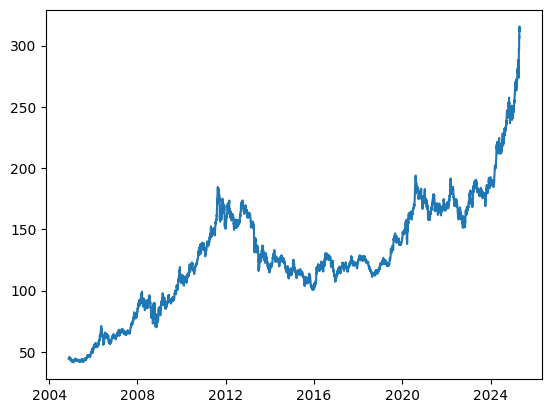

In [8]:
import matplotlib.pyplot as plt

plt.plot(df.index, df["Close"])

In [9]:
import numpy as np
import datetime


def str_to_datetime(s):
    split = s.split("-")
    year, month, day = int(split[0]), int(split[1]), int(split[2])
    return datetime.datetime(year=year, month=month, day=day)


# n = look back day that we have. So 3 indexs before
def df_to_windowed_df(dataframe, first_date_str, last_date_str, n=3):
    first_date = str_to_datetime(first_date_str)
    last_date = str_to_datetime(last_date_str)

    target_date = first_date

    dates = []
    X, Y = [], []

    last_time = False
    while True:
        df_subset = dataframe.loc[:target_date].tail(n + 1)

        if len(df_subset) != n + 1:
            print(f"Error: Window of size {n} is too large for date {target_date}")
            return

        values = df_subset["Close"].to_numpy()
        x, y = values[:-1], values[-1]

        dates.append(target_date)
        X.append(x)
        Y.append(y)

        next_week = dataframe.loc[
            target_date : target_date + datetime.timedelta(days=7)
        ]
        next_datetime_str = str(next_week.head(2).tail(1).index.values[0])
        next_date_str = next_datetime_str.split("T")[0]
        year_month_day = next_date_str.split("-")
        year, month, day = year_month_day
        next_date = datetime.datetime(day=int(day), month=int(month), year=int(year))

        if last_time:
            break

        target_date = next_date

        if target_date == last_date:
            last_time = True

    ret_df = pd.DataFrame({})
    ret_df["Target Date"] = dates

    X = np.array(X)
    for i in range(0, n):
        X[:, i]
        ret_df[f"Target-{n-i}"] = X[:, i]

    ret_df["Target"] = Y

    return ret_df

In [10]:
windowed_df = df_to_windowed_df(df, "2004-11-23", "2019-02-01", n=3)
windowed_df

,Target Date,Target-3,Target-2,Target-1,Target
0,2004-11-23,44.380001,44.779999,44.950001,44.750000
1,2004-11-24,44.779999,44.950001,44.750000,45.049999
2,2004-11-26,44.950001,44.750000,45.049999,45.290001
3,2004-11-29,44.750000,45.049999,45.290001,45.400002
4,2004-11-30,45.049999,45.290001,45.400002,45.119999
...,...,...,...,...,...
3567,2019-01-28,121.279999,121.089996,122.860001,123.290001
3568,2019-01-29,121.089996,122.860001,123.290001,123.980003
3569,2019-01-30,122.860001,123.290001,123.980003,124.690002
3570,2019-01-31,123.290001,123.980003,124.690002,124.750000


In [11]:
df

,Close
Date,
2004-11-18,44.380001
2004-11-19,44.779999
2004-11-22,44.950001
2004-11-23,44.750000
2004-11-24,45.049999
...,...
2025-04-15,297.779999
2025-04-16,307.470001
2025-04-17,306.119995


In [12]:
# date, Input -> X, output -> Y
def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()

    # getting the dates
    dates = df_as_np[:, 0]

    # we want the target window columns only and not the last one
    middle_matrix = df_as_np[:, 1:-1]
    # we need to reshape this
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

    # ouput vector
    Y = df_as_np[:, -1]

    return dates, X.astype(np.float32), Y.astype(np.float32)


dates, X, y = windowed_df_to_date_X_y(windowed_df)

# check all the shapes
dates.shape, X.shape, y.shape

((3572,), (3572, 3, 1), (3572,))

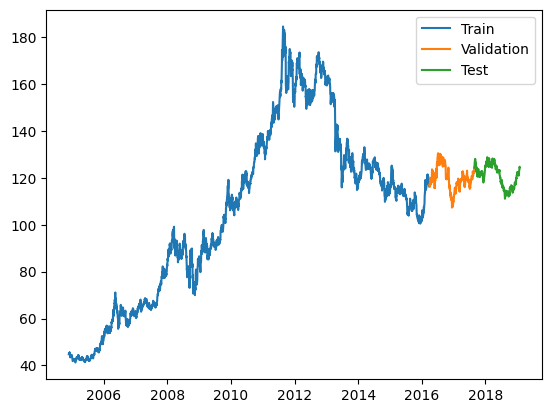

In [13]:
# training part
q_80 = int(len(dates) * 0.8)

# validation part
q_90 = int(len(dates) * 0.9)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(["Train", "Validation", "Test"])

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

model = Sequential(
    [
        layers.Input((3, 1)),  # window size = 3, feature = 1
        layers.LSTM(64),
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ]
)  # since the output we want is just 1

model.compile(
    loss="mse", optimizer=Adam(learning_rate=0.001), metrics=["mean_absolute_error"]
)

model.fit(
    X_train, y_train, validation_data=(X_val, y_val), epochs=100
)  # 100 runs through the dataset

Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11851.8682 - mean_absolute_error: 102.1190 - val_loss: 4850.7334 - val_mean_absolute_error: 69.4677
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2409.6536 - mean_absolute_error: 39.9169 - val_loss: 11.1720 - val_mean_absolute_error: 2.8378
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 97.0816 - mean_absolute_error: 4.8766 - val_loss: 1.1426 - val_mean_absolute_error: 0.7944
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.0462 - mean_absolute_error: 1.4697 - val_loss: 2.5572 - val_mean_absolute_error: 1.3325
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.4189 - mean_absolute_error: 1.2339 - val_loss: 1.1183 - val_mean_absolute_error: 0.7745
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.5507 - mean_absolute_error: 1.3369 - val_loss: 1.2279 - val_mean_absolute_error: 0.8255
Epoch 7/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.6302 - mean_absolute_error: 1

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step


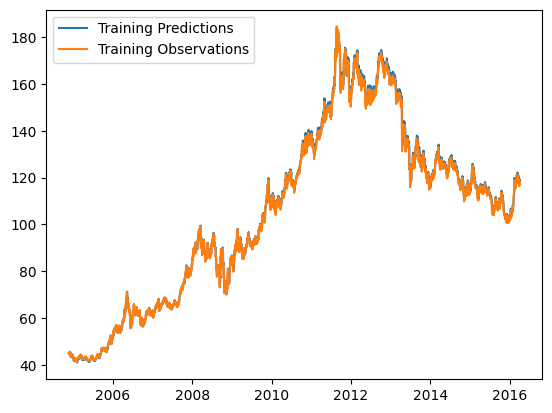

In [15]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(["Training Predictions", "Training Observations"])

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


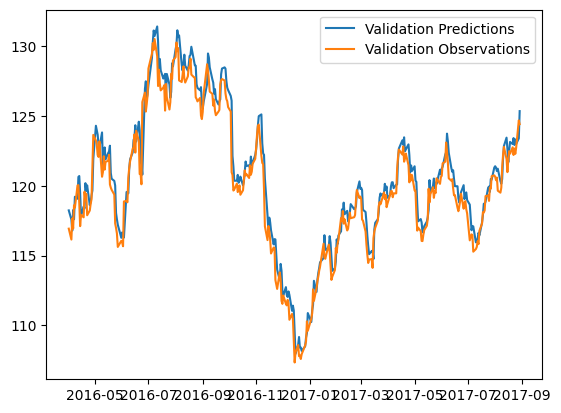

In [16]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(["Validation Predictions", "Validation Observations"])

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


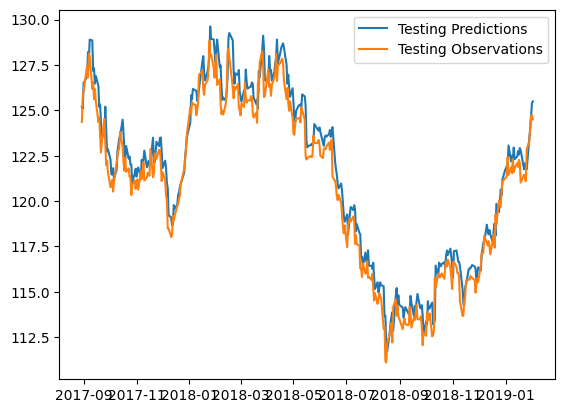

In [17]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(["Testing Predictions", "Testing Observations"])

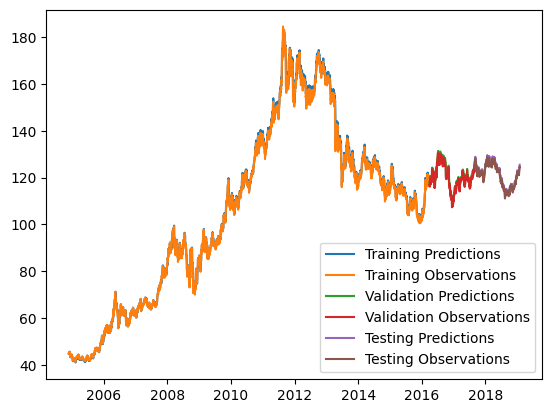

In [18]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(
    [
        "Training Predictions",
        "Training Observations",
        "Validation Predictions",
        "Validation Observations",
        "Testing Predictions",
        "Testing Observations",
    ]
)

In [19]:
from copy import deepcopy

recursive_predictions = []
recursive_dates = np.concatenate([dates_val, dates_test])

for target_date in recursive_dates:
    last_window = deepcopy(X_train[-1])
    next_prediction = model.predict(np.array([last_window])).flatten()
    recursive_predictions.append(next_prediction)
    last_window[-1] = next_prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━

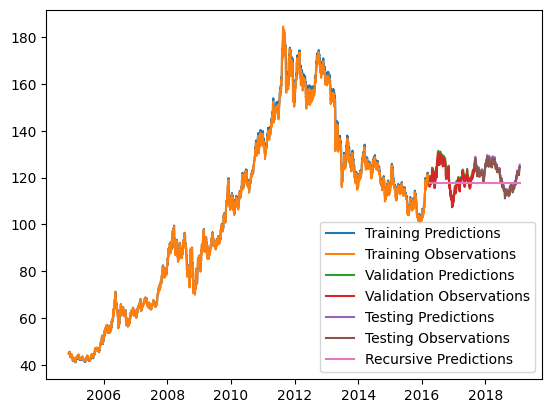

In [20]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.plot(recursive_dates, recursive_predictions)
plt.legend(
    [
        "Training Predictions",
        "Training Observations",
        "Validation Predictions",
        "Validation Observations",
        "Testing Predictions",
        "Testing Observations",
        "Recursive Predictions",
    ]
)